# FishSeg data exploration

Goal: confirm the DeepFish segmentation data is what we expect before writing
any model code. Check the image and mask pairing, the mask format, and the
balance of fish versus empty images.

Dataset: DeepFish (Saleh et al., 2020), segmentation subset. Underwater fish
footage from 20 habitats in tropical Australia. MIT licensed.

Format: each image has a matching mask. The mask is grayscale, white for fish
pixels and black for background. Roughly half the images contain no fish.

## 1. Load a split and look at the columns

In [1]:
import pandas as pd
from pathlib import Path

SEG = Path("../data/Segmentation")

train = pd.read_csv(SEG / "train.csv")

print(train.shape)
print(train.columns.to_list())
train.head()

(310, 5)
['ID', 'habitats', 'labels', 'classes', 'frames']


,ID,habitats,labels,classes,frames
0,valid/7623_F2_f000460,7623,1,valid,7623_F2_f000460
1,empty/7585_NF2_f000230,7585,0,empty,7585_NF2_f000230
2,empty/7434_NF3_f000160,7434,0,empty,7434_NF3_f000160
3,empty/7585_NF2_f000160,7585,0,empty,7585_NF2_f000160
4,valid/9866_acanthopagrus_palmaris_f000030,9866,1,valid,9866_acanthopagrus_palmaris_f000030


In [2]:
# The ID already encodes the path as "split/frame", e.g. "valid/7623_F2_f000460".
# So the image and mask paths can be built directly from the ID.
row = train.iloc[0]
print(dict(row))

images = list((SEG / "images").rglob("*.jpg"))
masks = list((SEG / "masks").rglob("*.png"))
print(f"\nFound {len(images)} images and {len(masks)} masks")

{'ID': 'valid/7623_F2_f000460', 'habitats': np.int64(7623), 'labels': np.int64(1), 'classes': 'valid', 'frames': '7623_F2_f000460'}

Found 620 images and 620 masks


## 2. Pair images and masks by ID (not by position)

`rglob` returns files in arbitrary order, so zipping the two lists together
would pair unrelated images and masks with no error raised. The only safe link
is the shared ID, so both paths are built from it and checked to exist.

In [3]:
def paths_from_id(row):
    """Return the image and mask paths for a row, built from its ID."""
    rel = row["ID"]
    image = SEG / "images" / f"{rel}.jpg"
    mask = SEG / "masks" / f"{rel}.png"
    return image, mask


# Confirm every row has both files present.
missing = []
for _, row in train.iterrows():
    img, msk = paths_from_id(row)
    if not img.exists() or not msk.exists():
        missing.append(row["ID"])

print(f"{len(train)} rows checked")
print(f"{len(missing)} rows with a missing file")

310 rows checked
0 rows with a missing file


## 3. Check one pair

Confirm the image and mask are the same size (so they align pixel for pixel)
and that the mask holds only two values, 0 and 255.

Image size: (1920, 1080), mode: RGB
Mask size : (1920, 1080), mode: L
Mask unique values: [  0 255]


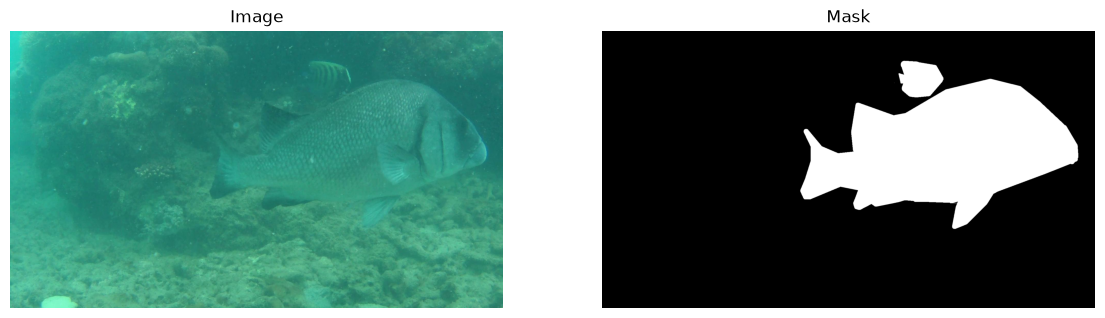

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

row = train.iloc[0]
img_path, mask_path = paths_from_id(row)

img = Image.open(img_path)
mask = Image.open(mask_path)

print(f"Image size: {img.size}, mode: {img.mode}")
print(f"Mask size : {mask.size}, mode: {mask.mode}")
print(f"Mask unique values: {np.unique(np.array(mask))}")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(img)
ax[0].set_title("Image")
ax[0].axis("off")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Mask")
ax[1].axis("off")
plt.show()

## 4. Fish versus empty balance

The paper notes about half the segmentation images have no fish. The empty
images are not filler: they teach the model what "no fish" looks like, which
matters for not raising false alarms on empty frames.

In [5]:
n = len(train)
fish = int((train["labels"] == 1).sum())

print(f"train: {n} total, {fish} with fish, {n - fish} empty ({(n - fish) / n:.0%} empty)")

train: 310 total, 149 with fish, 161 empty (52% empty)


## 5. Summary

- 310 training images, each with a matching mask, paired by ID with none missing.
- Images are 1920x1080 RGB. Masks are grayscale with values 0 and 255 only,
  so they need resizing with nearest-neighbour (no blending) later.
- 52% of images are empty, confirming the label column.